In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
shop = pd.read_csv('customer_shopping_data.csv')
shop.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [5]:
shop.shape

(99457, 10)

In [7]:
shop.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

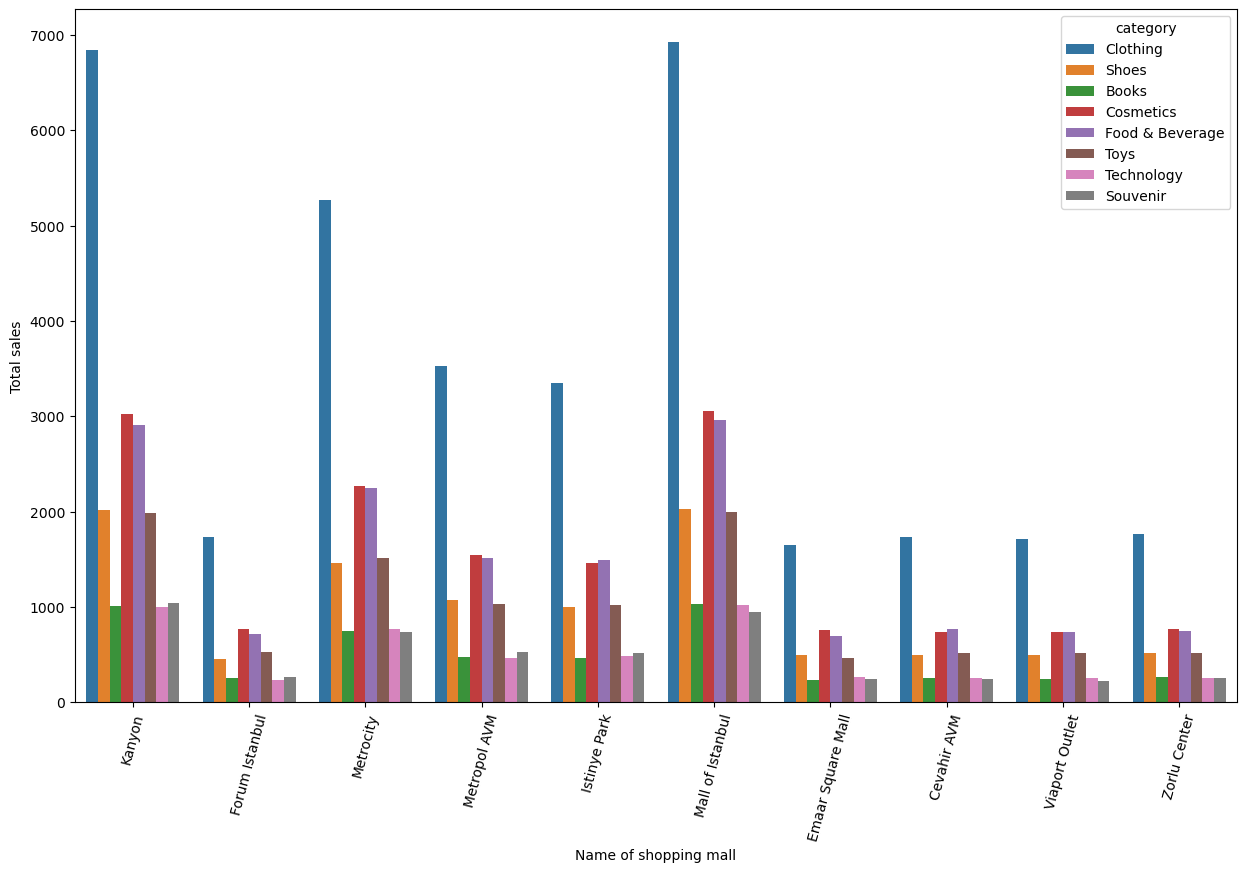

In [12]:
plt.figure(figsize=(15,9))
sns.countplot(x='shopping_mall',data = shop,hue = 'category')
plt.xlabel('Name of shopping mall')
plt.ylabel('Total sales')
plt.xticks(rotation = 75)


In [27]:
df_temp = pd.DataFrame(shop.groupby('shopping_mall')['price'].sum().round())
df_temp = df_temp.sort_values(by='price',ascending = False)
df_temp

,price
shopping_mall,
Mall of Istanbul,13851738.0
Kanyon,13710755.0
Metrocity,10249980.0
Metropol AVM,6937993.0
Istinye Park,6717078.0
Zorlu Center,3509649.0
Cevahir AVM,3433672.0
Viaport Outlet,3414019.0
Emaar Square Mall,3390408.0


In [23]:
df_temp.index

Index(['Cevahir AVM', 'Emaar Square Mall', 'Forum Istanbul', 'Istinye Park',
       'Kanyon', 'Mall of Istanbul', 'Metrocity', 'Metropol AVM',
       'Viaport Outlet', 'Zorlu Center'],
      dtype='object', name='shopping_mall')

([<matplotlib.patches.Wedge at 0x287bbb875b0>,
 [Text(0.9662271849063162, 0.7116214071737976, 'Mall of Istanbul'),
  Text(-0.35347766170770245, 1.0416590337887226, 'Kanyon'),
  Text(-1.0883659257765446, 0.15956068315398164, 'Metrocity'),
  Text(-0.8809061189921235, -0.6587901103706969, 'Metropol AVM'),
  Text(-0.32809802815417943, -1.0499293709204154, 'Istinye Park'),
  Text(0.18153790638111325, -1.0849165813770025, 'Zorlu Center'),
  Text(0.5118495502527934, -0.9736580703234649, 'Cevahir AVM'),
  Text(0.787412714013691, -0.7681023485249824, 'Viaport Outlet'),
  Text(0.9850958384258354, -0.48947542238206465, 'Emaar Square Mall'),
  Text(1.1860028125991389, -0.18274935979896567, 'Forum Istanbul')],
 [Text(0.5636325245286844, 0.4151124875180486, '20%'),
  Text(-0.19280599729511042, 0.5681776547938486, '20%'),
  Text(-0.5936541413326606, 0.0870330999021718, '15%'),
  Text(-0.48049424672297636, -0.3593400602021983, '10%'),
  Text(-0.1789625608113706, -0.572688747774772, '10%'),
  Text(0.09

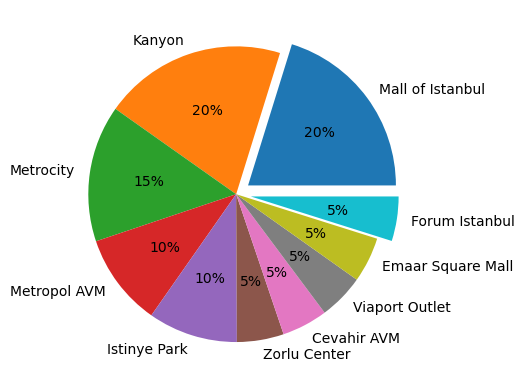

In [29]:
plt.pie(df_temp['price'],labels= df_temp.index,autopct='%1.0f%%',explode = (.1,0,0,0,0,0,0,0,0,.1))

In [30]:
shop.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [47]:
shop['Total_shop'] = shop['quantity']*shop['price']
df_cat = pd.DataFrame(shop.groupby('category')['Total_shop'].sum().round())
df_cat

,Total_shop
category,
Books,8.345529e+05
Clothing,1.139968e+08
Cosmetics,6.792863e+06
Food & Beverage,8.495351e+05
Shoes,6.655345e+07
Souvenir,6.358247e+05
Technology,5.786235e+07
Toys,3.980426e+06


In [48]:
df_cat.index

Index(['Books', 'Clothing', 'Cosmetics', 'Food & Beverage', 'Shoes',
       'Souvenir', 'Technology', 'Toys'],
      dtype='object', name='category')

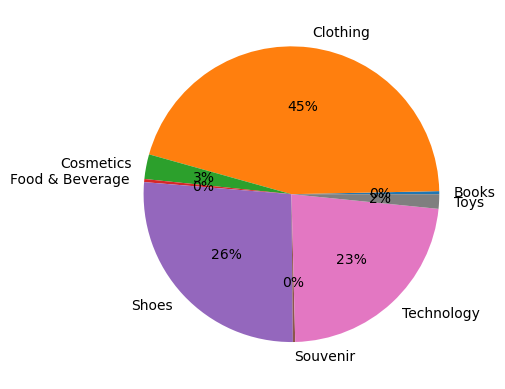

In [53]:
plt
plt.pie(x=df_cat['Total_shop'],labels=df_cat.index,autopct='%1.0f%%')
plt.show()

In [ ]:
# Aim  with each shopping mall representation of each category
# Stacked bar plot

In [57]:
abcd = shop.groupby(['shopping_mall','category'])['price'].sum().round().unstack()

In [58]:
abcd

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,11999.0,1554414.0,88395.0,11992.0,884050.0,8305.0,819000.0,55516.0
Emaar Square Mall,11060.0,1511803.0,92380.0,11030.0,871447.0,8516.0,834750.0,49423.0
Forum Istanbul,11453.0,1572119.0,95226.0,10837.0,875648.0,9091.0,706650.0,55050.0
Istinye Park,20725.0,3050313.0,178741.0,23420.0,1806512.0,18369.0,1509900.0,109097.0
Kanyon,44980.0,6155541.0,372242.0,45475.0,3640031.0,35483.0,3202500.0,214502.0
Mall of Istanbul,46950.0,6245565.0,373787.0,46432.0,3668239.0,34263.0,3220350.0,216151.0
Metrocity,34406.0,4719958.0,272422.0,35376.0,2610139.0,25771.0,2386650.0,165258.0
Metropol AVM,22240.0,3166444.0,185776.0,23985.0,1942750.0,18604.0,1465800.0,112394.0
Viaport Outlet,10908.0,1530708.0,92664.0,11433.0,882850.0,7636.0,823200.0,54620.0


### Stacked Bar plot

<AxesSubplot:xlabel='shopping_mall'>

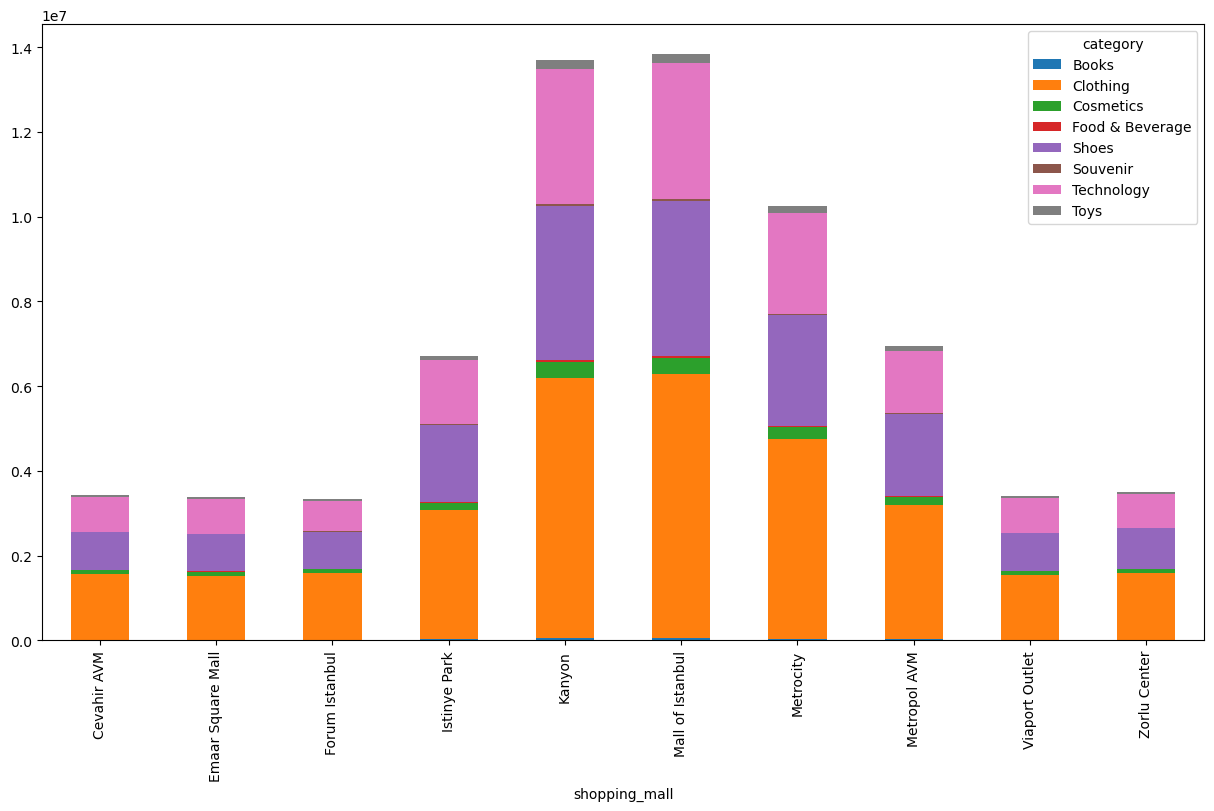

In [59]:
abcd.plot(kind = 'bar', stacked =True, figsize = (15,8))

In [ ]:
# stacked bar plot which states which gender buy what types of category. f

In [73]:
shop_cat = shop.groupby(['gender','category'])['price'].sum().round().unstack()

In [74]:
shop_cat

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
gender,,,,,,,,
Female,132956.0,18616663.0,1108432.0,137873.0,10746644.0,105288.0,9425850.0,658094.0
Male,94021.0,12459022.0,740175.0,93695.0,7388693.0,69148.0,6346200.0,428611.0


In [81]:
shop_cat = shop_cat.loc[:, [ 'Clothing', 'Shoes','Technology','Cosmetics', 'Toys' ,'Books',  'Food & Beverage']]

<AxesSubplot:xlabel='gender'>

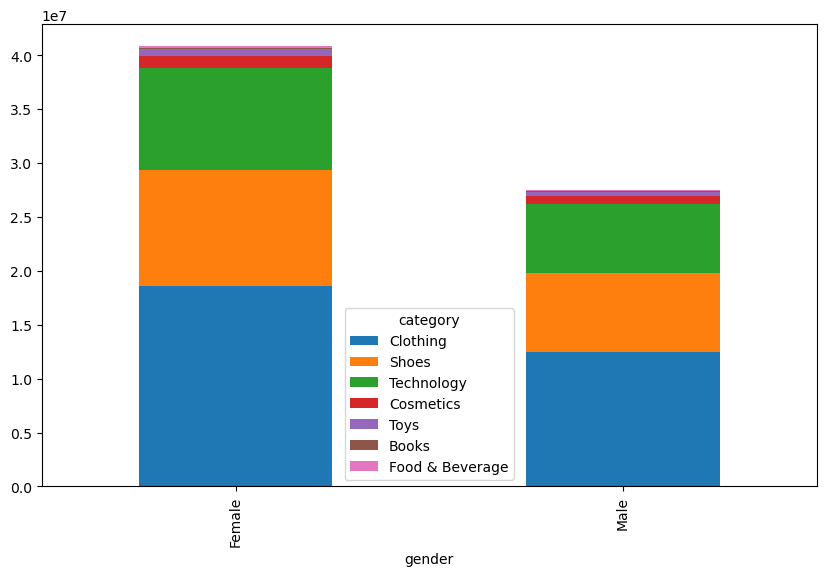

In [82]:
shop_cat.plot(kind = 'bar', stacked = True,figsize = (10,6))

### Subplots

In [127]:
df1 = pd.DataFrame(shop.gender.value_counts())
df2 = pd.DataFrame(shop.shopping_mall.value_counts())
df3 = pd.DataFrame(shop.category.value_counts())
df4 = pd.DataFrame(shop.age.value_counts())

df1

,count
gender,
Female,59482
Male,39975


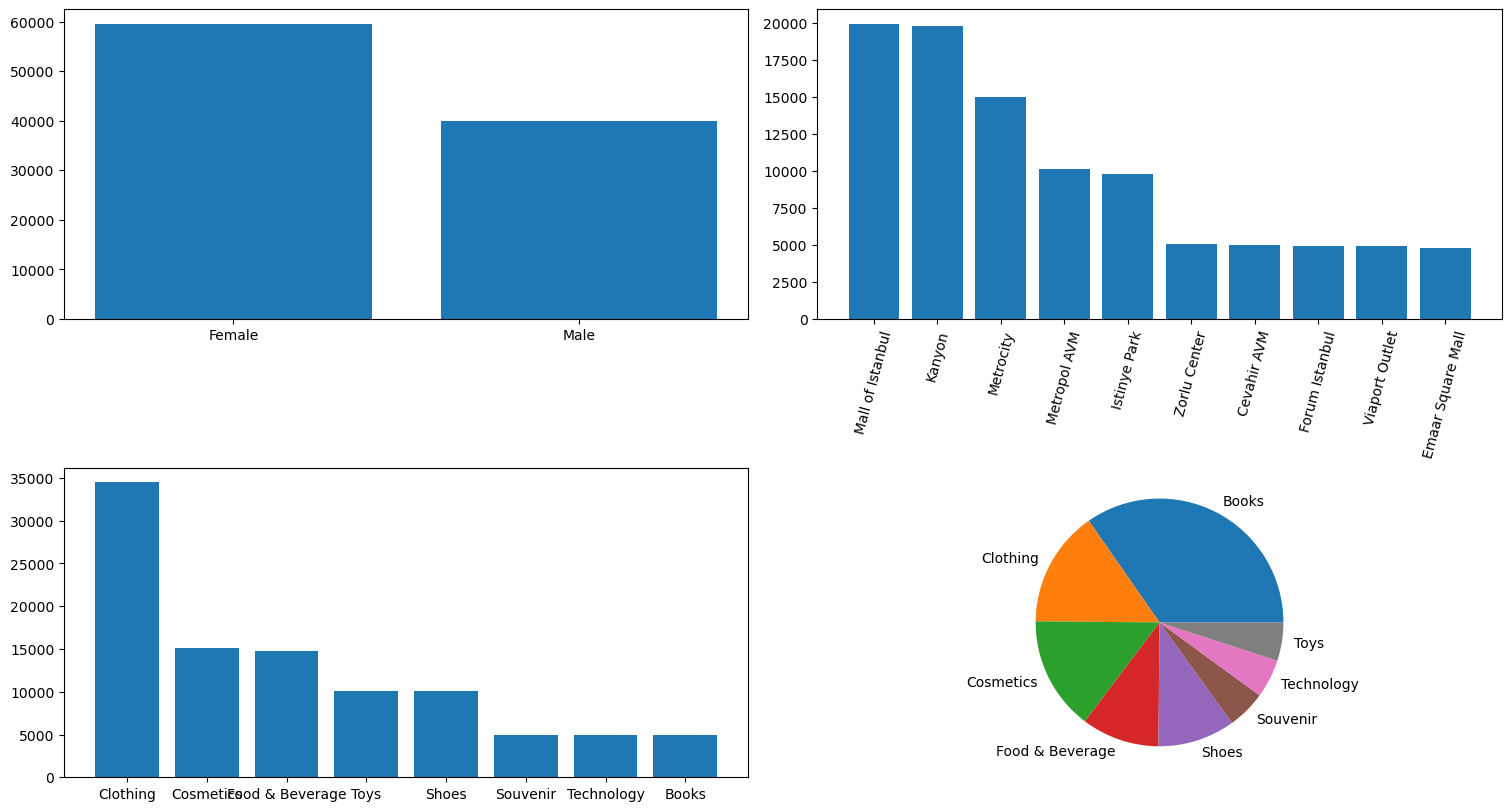

In [139]:
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize=(15,8) , constrained_layout= True)
ax[0,0].bar(df1.index, df1['Numbers'])
ax[0,1].bar(df2.index, df2['Numbers'])
ax[1,0].bar(df3.index, df3['Numbers'])
ax[1,1].pie(df3['Numbers'],labels=df_cat.index)

ax[0,1].tick_params(axis = 'x', rotation = 75)

In [99]:
df1 =pd.DataFrame(shop.gender.value_counts())

In [128]:
df1.columns = ['Numbers']
df2.columns =['Numbers']
df3.columns =['Numbers']
df4.columns =['Numbers']

In [117]:
df1

,Numbers
gender,
Female,59482
Male,39975


In [132]:
plt.figure(figsize=(5,5))
plt.pie(x=df, df4['Numbers'])

([<matplotlib.patches.Wedge at 0x287be25ed90>,
 [Text(2055.383192380935, 105.71443836088606, ''),
  Text(2033.8869761710857, 272.7969540915676, ''),
  Text(1939.447372792716, 500.9525907383178, ''),
  Text(1842.0584564771525, 781.8067874615888, ''),
  Text(1718.572834241637, 1011.4060625716393, ''),
  Text(1584.575491337078, 1190.7312552603373, ''),
  Text(1487.8933921526461, 1303.4772202031352, ''),
  Text(1354.5678288407357, 1418.1181922074393, ''),
  Text(1168.5861220554068, 1568.6725870427854, ''),
  Text(977.5499966973821, 1693.1662688457234, ''),
  Text(798.6821312040955, 1784.5231473128288, ''),
  Text(631.6573538356548, 1849.1932828521033, ''),
  Text(487.9479639433631, 1889.0997841521043, ''),
  Text(312.4971977741489, 1922.8726196457487, ''),
  Text(151.36259449674375, 1942.2108472015118, ''),
  Text(-70.25891750567365, 1944.8313280361697, ''),
  Text(-373.36729847192385, 1909.9481852740869, ''),
  Text(-556.9982363695225, 1855.2922612573045, ''),
  Text(-739.1736037748825, 1

ValueError: Image size of 608724x588378 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 500x500 with 1 Axes>

([<matplotlib.patches.Wedge at 0x287be4dad00>,
 [Text(0.5093615854958602, 0.9749619352678051, 'Books'),
  Text(-0.972626882345222, 0.5138063329109657, 'Clothing'),
  Text(-0.9868233231842816, -0.48598325981409213, 'Cosmetics'),
  Text(-0.3541885035415419, -1.0414175454441907, 'Food & Beverage'),
  Text(0.33319698751395715, -1.0483223585861479, 'Shoes'),
  Text(0.7756339668314125, -0.7799948394043178, 'Souvenir'),
  Text(0.979484168908071, -0.5006103902821691, 'Technology'),
  Text(1.086412858946468, -0.1723574771101099, 'Toys')])

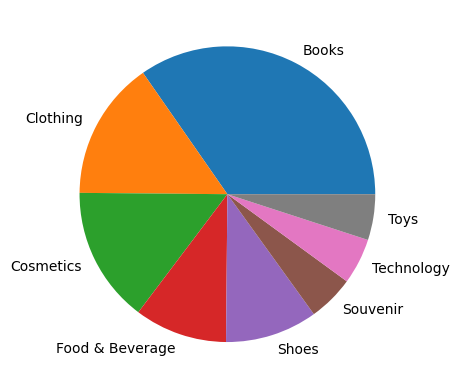

In [138]:
plt.pie(df3['Numbers'],labels=df_cat.index)